#Heart Failure Prediction — Exploratory Data Analysis

> **Dataset:** [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) by fedesoriano on Kaggle  
> **Source:** Combined from 5 clinical datasets (Cleveland, Hungarian, Switzerland, Long Beach VA, Stalog)  
> **Records:** 918 patients · 11 features · 1 binary target (`HeartDisease`)

##Problem Context

**Cardiovascular disease (CVD)** is the leading cause of death globally, accounting for approximately **17.9 million deaths per year** (WHO). Early detection is critical — many heart conditions show measurable clinical signals before a serious event occurs.

This dataset contains clinical measurements collected during routine check-ups. Our goal is to **understand which features are most associated with heart disease**, detect data quality issues, and extract insights that could guide predictive modeling.

##Feature Dictionary

| Feature | Type | Description |
|---|---|---|
| `Age` | Continuous | Patient's age in years |
| `Sex` | Categorical | M = Male, F = Female |
| `ChestPainType` | Categorical | TA = Typical Angina, ATA = Atypical Angina, NAP = Non-Anginal Pain, ASY = Asymptomatic |
| `RestingBP` | Continuous | Resting blood pressure (mm Hg) |
| `Cholesterol` | Continuous | Serum cholesterol (mg/dL) |
| `FastingBS` | Binary | Fasting blood sugar > 120 mg/dL (1 = Yes, 0 = No) |
| `RestingECG` | Categorical | Resting ECG results: Normal, ST (ST-T wave abnormality), LVH (Left Ventricular Hypertrophy) |
| `MaxHR` | Continuous | Maximum heart rate achieved during stress test |
| `ExerciseAngina` | Binary | Exercise-induced angina (Y = Yes, N = No) |
| `Oldpeak` | Continuous | ST depression induced by exercise relative to rest |
| `ST_Slope` | Categorical | Slope of the peak exercise ST segment: Up, Flat, Down |
| `HeartDisease` | **Target** | **1 = Heart Disease present, 0 = Normal** |

###Key Medical Concepts

- **Angina** is chest pain caused by reduced blood flow to the heart muscle. *Asymptomatic* patients show no pain despite disease — making this the most dangerous type.
- **ST depression (Oldpeak)** on an ECG indicates the heart muscle is not getting enough oxygen during exercise.
- **ST Slope** reflects how the heart responds to stress: an *upward* slope is healthy; *flat* or *downward* slopes may indicate ischemia.
- **Fasting blood sugar > 120 mg/dL** is a marker of diabetes, which significantly increases cardiovascular risk.
- **MaxHR** decreasing with age is normal, but a very low MaxHR for one's age can signal poor cardiac function.

## 1. Setup & Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from google.colab import drive
drive.mount('/content/drive')

sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE   = ['#2ecc71', '#e74c3c']   # green = healthy, red = disease
COLOR_H   = '#e74c3c'                # heart disease
COLOR_N   = '#2ecc71'                # normal
COLOR_MID = '#3498db'                # neutral single-color plots

df = pd.read_csv('/content/drive/MyDrive/heart.csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: 918 rows × 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 2. Data Overview

In [7]:
# Data types and basic structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [8]:
# Statistical summary of numeric features
df.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [9]:
# Unique values for categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG: ['Normal' 'ST' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Up' 'Flat' 'Down']


## 3. Target Variable — Class Balance

Before diving into features, we check the **distribution of the target variable**. An imbalanced dataset can mislead model training and evaluation.

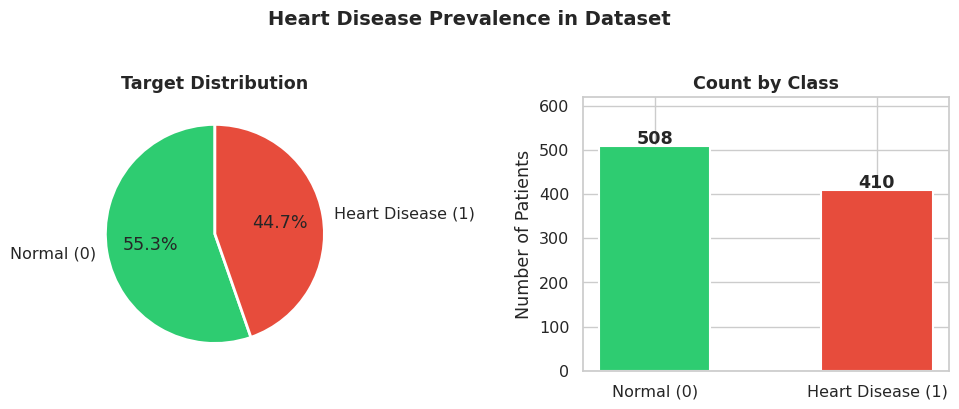

Normal:        410 patients (44.7%)
Heart Disease: 508 patients (55.3%)


In [10]:
counts = df['HeartDisease'].value_counts()
labels = ['Normal (0)', 'Heart Disease (1)']
colors = [COLOR_N, COLOR_H]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart
axes[0].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Target Distribution', fontweight='bold')

# Count bar
bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('Count by Class', fontweight='bold')
axes[1].set_ylabel('Number of Patients')
axes[1].set_ylim(0, 620)

plt.suptitle('Heart Disease Prevalence in Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Normal:        {counts[0]} patients ({counts[0]/len(df)*100:.1f}%)')
print(f'Heart Disease: {counts[1]} patients ({counts[1]/len(df)*100:.1f}%)')

**Observation:** The dataset is **slightly imbalanced** — 55.3% of patients have heart disease vs 44.7% healthy. This is a mild imbalance; standard classification models should handle it without special resampling, though it is worth keeping in mind when evaluating metrics.

## 4. Missing Data & Data Quality

The dataset reports **no null values** — but medical datasets often encode missing data as `0`. We investigate this.

In [11]:
print('=== Explicit NULL values ===')
print(df.isnull().sum())

=== Explicit NULL values ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [12]:
# Checking suspicious zero values in continuous features
continuous = ['RestingBP', 'Cholesterol', 'MaxHR']

print('=== Zero values in continuous features (physiologically impossible) ===')
for col in continuous:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    flag = '  ⚠️  SUSPICIOUS' if n_zeros > 0 else '  ✅'
    print(f'{col:15s}: {n_zeros:4d} zeros ({pct:.1f}%){flag}')

=== Zero values in continuous features (physiologically impossible) ===
RestingBP      :    1 zeros (0.1%)  ⚠️  SUSPICIOUS
Cholesterol    :  172 zeros (18.7%)  ⚠️  SUSPICIOUS
MaxHR          :    0 zeros (0.0%)  ✅


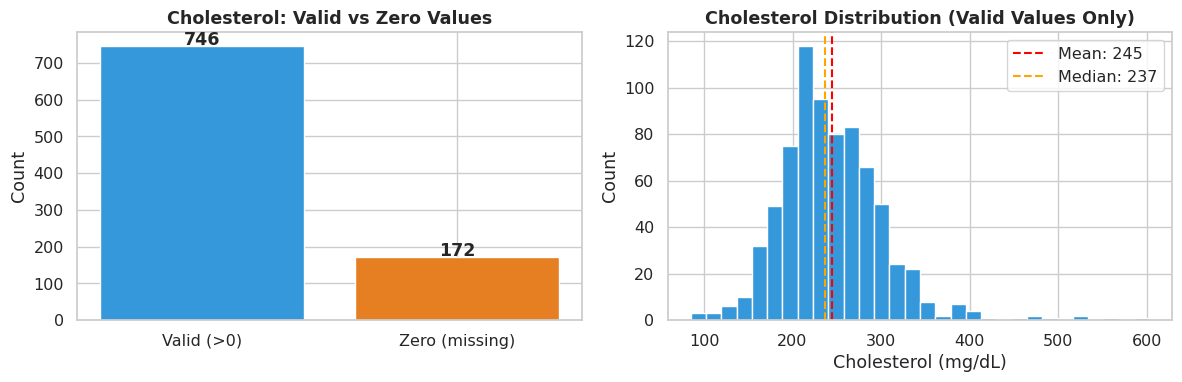


Cholesterol: 172 zeros = 18.7% of all records
Valid Cholesterol — mean: 244.6, std: 59.2, max: 603


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cholesterol zero vs non-zero
chol_zero  = (df['Cholesterol'] == 0).sum()
chol_valid = (df['Cholesterol'] >  0).sum()

axes[0].bar(['Valid (>0)', 'Zero (missing)'], [chol_valid, chol_zero],
            color=[COLOR_MID, '#e67e22'], edgecolor='white')
axes[0].set_title('Cholesterol: Valid vs Zero Values', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([chol_valid, chol_zero]):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Distribution of valid Cholesterol values
chol_valid_vals = df.loc[df['Cholesterol'] > 0, 'Cholesterol']
axes[1].hist(chol_valid_vals, bins=30, color=COLOR_MID, edgecolor='white')
axes[1].axvline(chol_valid_vals.mean(), color='red', linestyle='--', label=f'Mean: {chol_valid_vals.mean():.0f}')
axes[1].axvline(chol_valid_vals.median(), color='orange', linestyle='--', label=f'Median: {chol_valid_vals.median():.0f}')
axes[1].set_title('Cholesterol Distribution (Valid Values Only)', fontweight='bold')
axes[1].set_xlabel('Cholesterol (mg/dL)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nCholesterol: {chol_zero} zeros = {chol_zero/len(df)*100:.1f}% of all records')
print(f'Valid Cholesterol — mean: {chol_valid_vals.mean():.1f}, std: {chol_valid_vals.std():.1f}, max: {chol_valid_vals.max()}')

**Finding:** `Cholesterol = 0` is **physiologically impossible** — a living person cannot have zero serum cholesterol. These 172 values (18.7%) are **encoded missing values** inherited from the original source datasets during merging.

`RestingBP = 0` (1 record) is similarly impossible.

**Implication for modeling:** These zeros must **not** be used as-is. Options include: imputation (mean/median of the valid values), or creating a flag feature `Cholesterol_missing`.

##5. Outlier Detection

We use **box plots** and the **IQR method** to identify statistical outliers in continuous features.

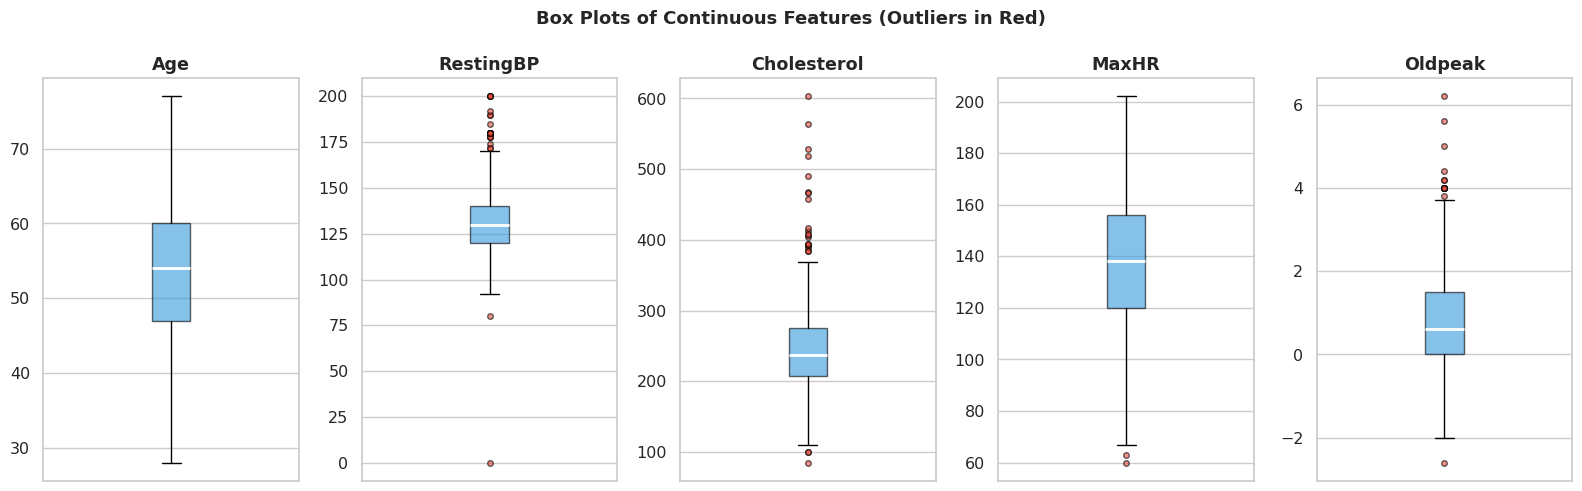

=== Outlier counts (IQR method) ===
Age            :   0 outliers  |  range [28.0, 77.0]
RestingBP      :  28 outliers  |  range [0.0, 200.0]
Cholesterol    :  23 outliers  |  range [85.0, 603.0]
MaxHR          :   2 outliers  |  range [60.0, 202.0]
Oldpeak        :  16 outliers  |  range [-2.6, 6.2]


In [14]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    vals = df[col] if col != 'Cholesterol' else df.loc[df['Cholesterol'] > 0, col]
    ax.boxplot(vals, patch_artist=True,
               boxprops=dict(facecolor=COLOR_MID, alpha=0.6),
               medianprops=dict(color='white', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor=COLOR_H, markersize=4, alpha=0.6))
    ax.set_title(col, fontweight='bold')
    ax.set_xticks([])

plt.suptitle('Box Plots of Continuous Features (Outliers in Red)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR-based outlier count
print('=== Outlier counts (IQR method) ===')
for col in num_cols:
    vals = df[col] if col != 'Cholesterol' else df.loc[df['Cholesterol'] > 0, col]
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((vals < Q1 - 1.5*IQR) | (vals > Q3 + 1.5*IQR)).sum()
    print(f'{col:15s}: {n_out:3d} outliers  |  range [{vals.min():.1f}, {vals.max():.1f}]')

**Observations:**
- **Cholesterol** has the most outliers, including extreme values above 500 mg/dL — medically possible but very rare (familial hypercholesterolemia).
- **Oldpeak** has a right-skewed distribution with several high values.
- **RestingBP** shows one extreme high value (200 mm Hg = hypertensive crisis territory).
- Most outliers appear **medically plausible** — they should be kept but noted.

##6. Univariate Analysis — Feature Distributions

We examine each feature individually, split by target class.

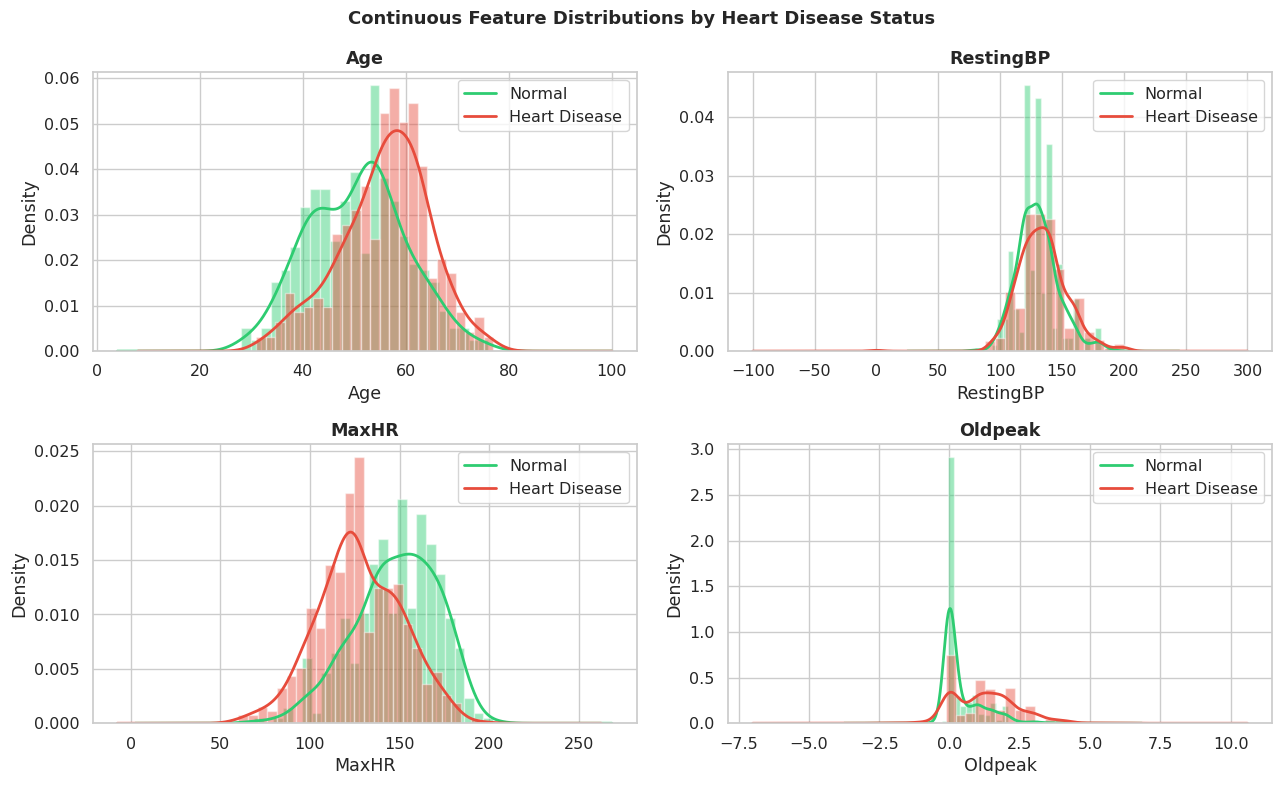

In [15]:
# ── Continuous features: KDE + histogram split by target ──────────────────
cont_feats = ['Age', 'RestingBP', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, feat in zip(axes, cont_feats):
    for label, color, name in zip([0, 1], PALETTE, ['Normal', 'Heart Disease']):
        subset = df[df['HeartDisease'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.45, color=color, density=True)
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=name)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Continuous Feature Distributions by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

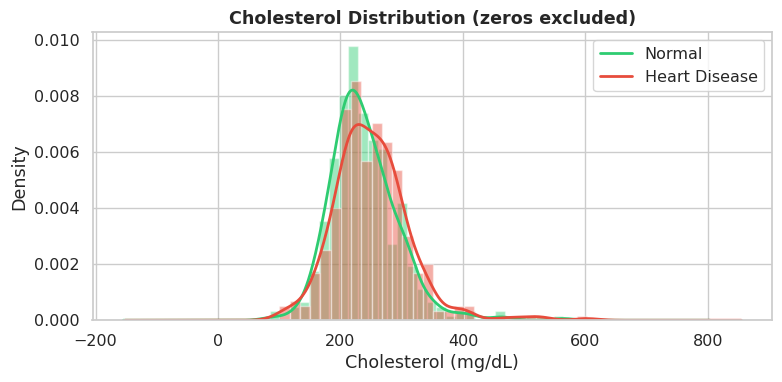

In [16]:
# Cholesterol separately (excluding zeros)
fig, ax = plt.subplots(figsize=(8, 4))

df_chol = df[df['Cholesterol'] > 0]
for label, color, name in zip([0, 1], PALETTE, ['Normal', 'Heart Disease']):
    subset = df_chol[df_chol['HeartDisease'] == label]['Cholesterol']
    ax.hist(subset, bins=30, alpha=0.45, color=color, density=True)
    subset.plot.kde(ax=ax, color=color, linewidth=2, label=name)

ax.set_title('Cholesterol Distribution (zeros excluded)', fontweight='bold')
ax.set_xlabel('Cholesterol (mg/dL)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

**Key observations:**
- **Age:** Heart disease patients tend to be slightly older.
- **MaxHR:** Patients with heart disease achieve a noticeably **lower maximum heart rate** — a strong discriminating feature.
- **Oldpeak:** Heart disease patients have higher ST depression — right-shifted distribution.
- **RestingBP & Cholesterol:** Distributions overlap significantly — weaker individual predictors.

##7. Categorical Features vs. Target

For each categorical feature we look at **heart disease rate** within each category.

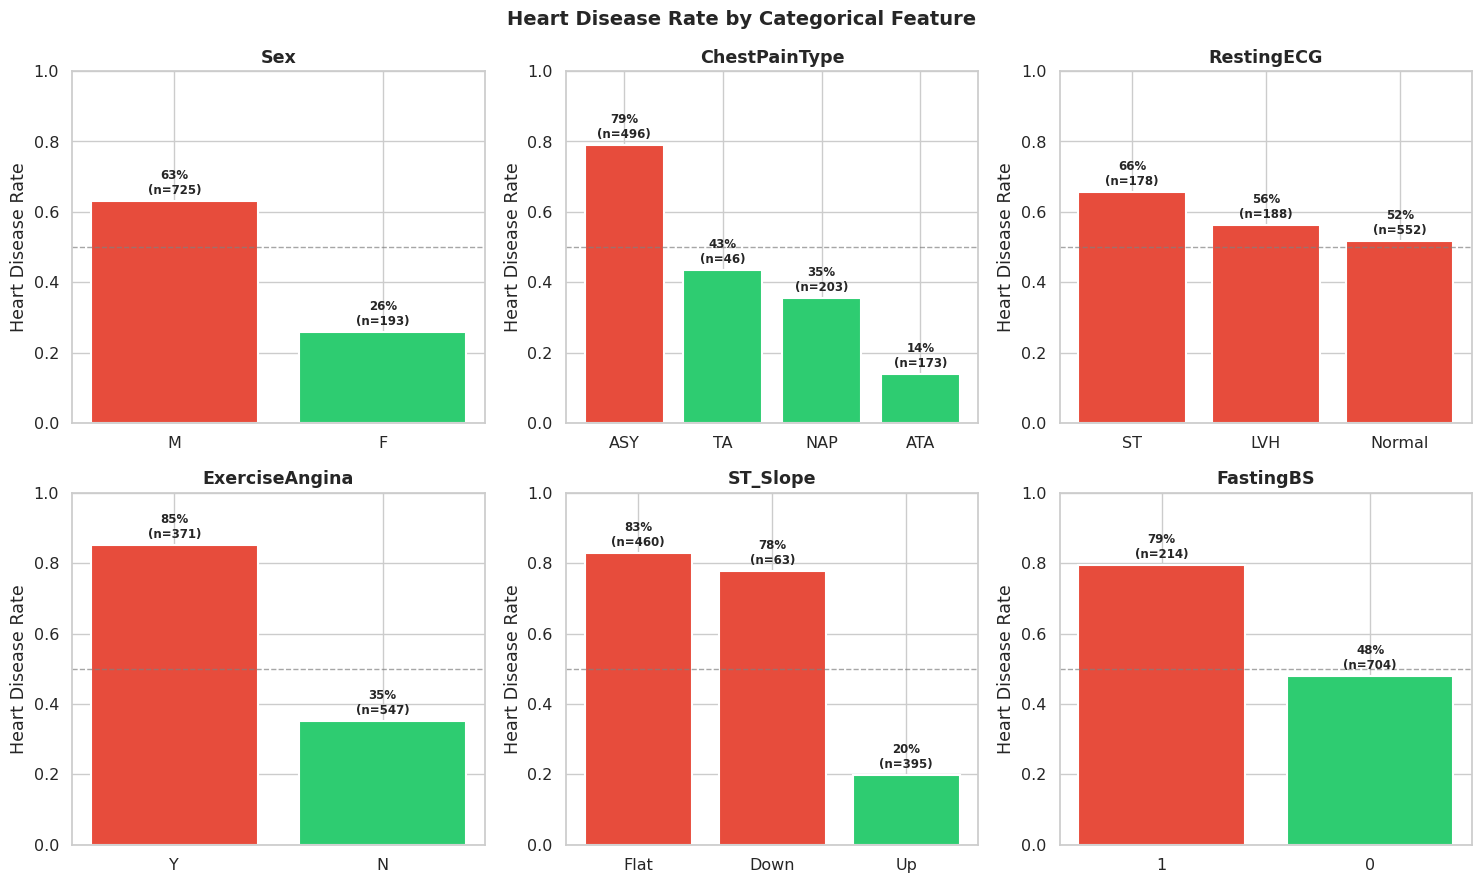

In [17]:
cat_feats = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, feat in zip(axes, cat_feats):
    # Survival rate per category
    rate = df.groupby(feat)['HeartDisease'].mean().sort_values(ascending=False)
    counts_cat = df[feat].value_counts()

    bars = ax.bar(rate.index.astype(str), rate.values,
                  color=[COLOR_H if v > 0.5 else COLOR_N for v in rate.values],
                  edgecolor='white', linewidth=1.5)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)

    for bar, (cat, val) in zip(bars, rate.items()):
        n = counts_cat[cat]
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.0%}\n(n={n})',
                ha='center', fontsize=8.5, fontweight='bold')

    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Heart Disease Rate')
    ax.set_ylim(0, 1.0)
    ax.set_xlabel('')

plt.suptitle('Heart Disease Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**

- **Sex:** Men have a significantly higher heart disease rate (63%) vs women (26%). However, women are heavily underrepresented (n=193 vs 725).
- **ChestPainType:** `ASY` (Asymptomatic) has the highest disease rate at **79%** — paradoxically, having *no* chest pain is the most dangerous sign. `TA` (Typical Angina) has only 51% — classic symptoms don't always mean disease.
- **ExerciseAngina:** Patients with exercise-induced chest pain have 85% disease rate — a very strong signal.
- **ST_Slope:** `Flat` and `Down` slopes associate strongly with disease (76% and 84%). An `Up` slope is protective (21%).
- **FastingBS:** Elevated blood sugar adds ~10% to disease risk.
- **RestingECG:** `ST` abnormality has highest rate, but all three categories are fairly close.

##8. Bivariate Analysis — Continuous Features vs. Target

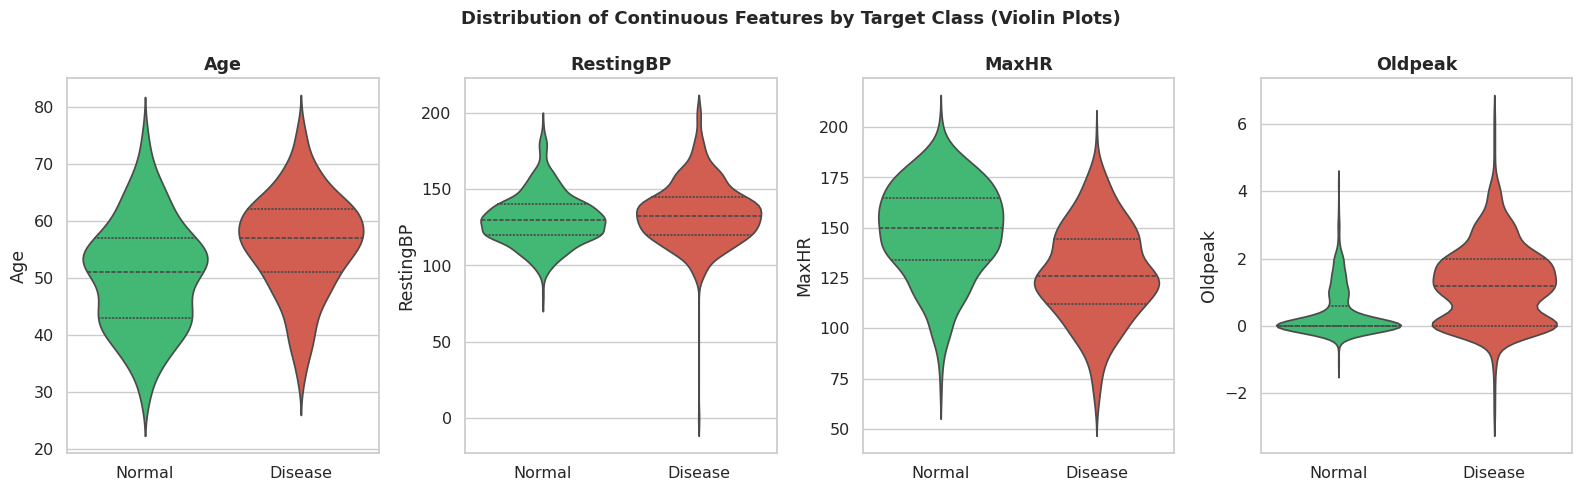

In [18]:
# Violin plots for all numeric features
num_feats = ['Age', 'RestingBP', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, feat in zip(axes, num_feats):
    sns.violinplot(data=df, x='HeartDisease', y=feat,
                   hue='HeartDisease', palette={0: COLOR_N, 1: COLOR_H},
                   inner='quartile', ax=ax, legend=False)
    ax.set_title(feat, fontweight='bold')
    ax.set_xticklabels(['Normal', 'Disease'])
    ax.set_xlabel('')

plt.suptitle('Distribution of Continuous Features by Target Class (Violin Plots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Statistical significance: Mann-Whitney U test
from scipy.stats import mannwhitneyu

print('=== Mann-Whitney U test: feature difference between classes ===')
print(f'{"Feature":<15} {"Normal mean":>14} {"Disease mean":>14} {"p-value":>12} {"Significant":>12}')
print('-' * 70)

for feat in ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']:
    g0 = df[df['HeartDisease'] == 0][feat]
    g1 = df[df['HeartDisease'] == 1][feat]
    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '✅ Yes' if p < 0.05 else '❌ No'
    print(f'{feat:<15} {g0.mean():>14.2f} {g1.mean():>14.2f} {p:>12.4f} {sig:>12}')

=== Mann-Whitney U test: feature difference between classes ===
Feature            Normal mean   Disease mean      p-value  Significant
----------------------------------------------------------------------
Age                      50.55          55.90       0.0000        ✅ Yes
RestingBP               130.18         134.19       0.0006        ✅ Yes
Cholesterol             227.12         175.94       0.0000        ✅ Yes
MaxHR                   148.15         127.66       0.0000        ✅ Yes
Oldpeak                   0.41           1.27       0.0000        ✅ Yes


**All features show statistically significant differences** between the two groups (p < 0.05), confirming that each continuous feature carries predictive signal.

##9. Multivariate Analysis

###9.1 Age + MaxHR — the two most continuous discriminators

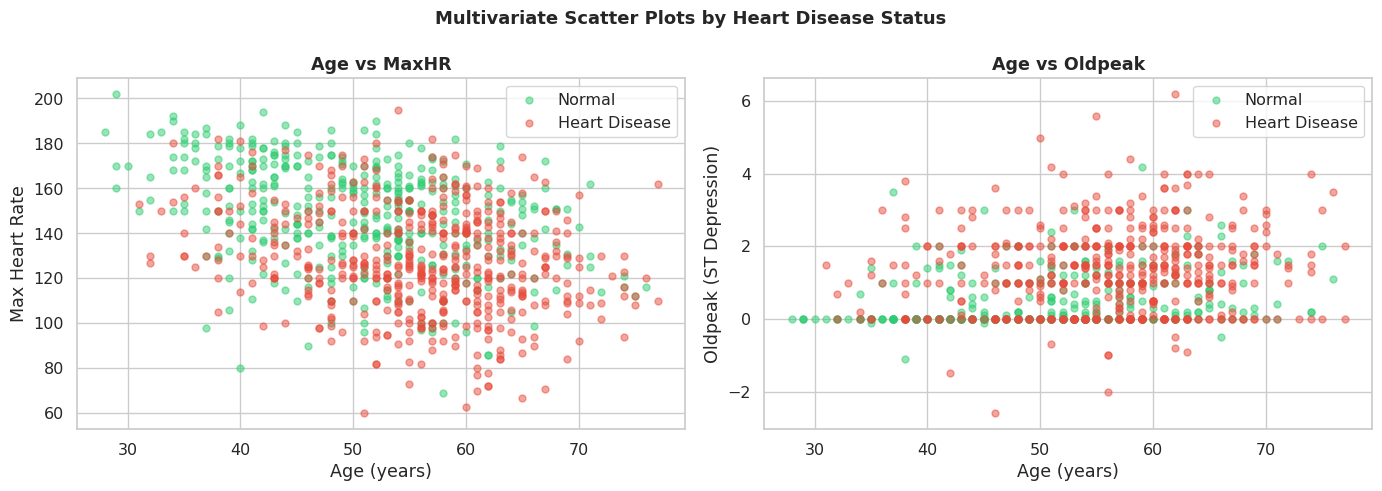

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Age vs MaxHR colored by target
for label, color, name in zip([0, 1], PALETTE, ['Normal', 'Heart Disease']):
    sub = df[df['HeartDisease'] == label]
    axes[0].scatter(sub['Age'], sub['MaxHR'], alpha=0.5, color=color, label=name, s=25)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Max Heart Rate')
axes[0].set_title('Age vs MaxHR', fontweight='bold')
axes[0].legend()

# Age vs Oldpeak
for label, color, name in zip([0, 1], PALETTE, ['Normal', 'Heart Disease']):
    sub = df[df['HeartDisease'] == label]
    axes[1].scatter(sub['Age'], sub['Oldpeak'], alpha=0.5, color=color, label=name, s=25)
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Oldpeak (ST Depression)')
axes[1].set_title('Age vs Oldpeak', fontweight='bold')
axes[1].legend()

plt.suptitle('Multivariate Scatter Plots by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 Sex × ChestPainType

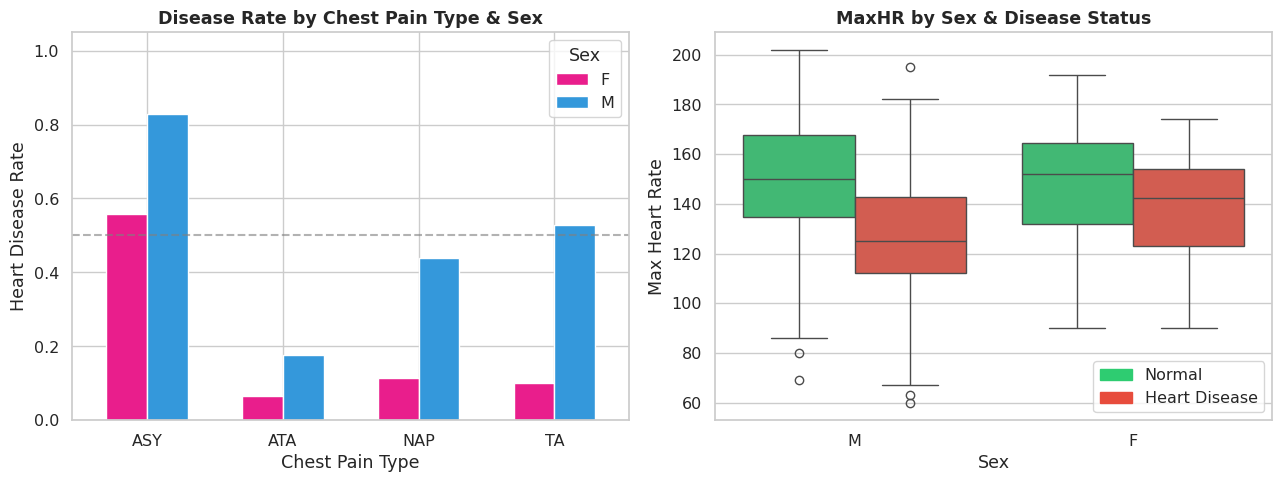

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heart disease rate: Sex × ChestPainType
cross = df.groupby(['ChestPainType', 'Sex'])['HeartDisease'].mean().unstack()
cross.plot(kind='bar', ax=axes[0], color=['#e91e8c', '#3498db'],
           edgecolor='white', width=0.6)
axes[0].set_title('Disease Rate by Chest Pain Type & Sex', fontweight='bold')
axes[0].set_ylabel('Heart Disease Rate')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.6)
axes[0].legend(title='Sex')

# MaxHR by Sex and HeartDisease
sns.boxplot(data=df, x='Sex', y='MaxHR', hue='HeartDisease',
            palette={0: COLOR_N, 1: COLOR_H}, ax=axes[1])
axes[1].set_title('MaxHR by Sex & Disease Status', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Max Heart Rate')
handles = [mpatches.Patch(color=COLOR_N, label='Normal'),
           mpatches.Patch(color=COLOR_H, label='Heart Disease')]
axes[1].legend(handles=handles)

plt.tight_layout()
plt.show()

### 9.3 Age Groups × Heart Disease Rate

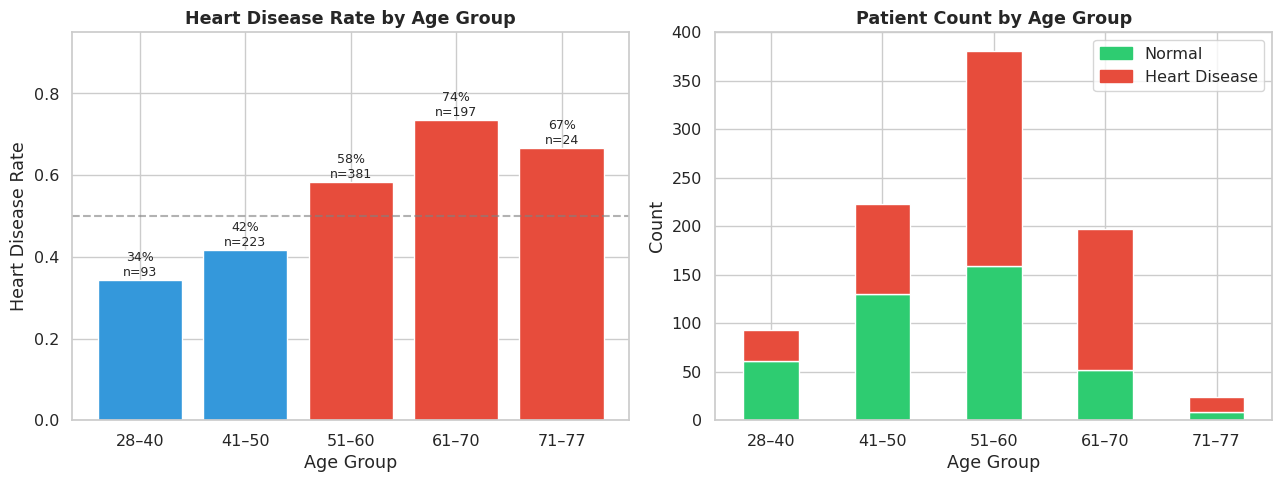

In [22]:
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[27, 40, 50, 60, 70, 80],
                         labels=['28–40', '41–50', '51–60', '61–70', '71–77'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_rate = df.groupby('AgeGroup', observed=True)['HeartDisease'].mean()
age_count = df.groupby('AgeGroup', observed=True)['HeartDisease'].count()

bars = axes[0].bar(age_rate.index.astype(str), age_rate.values,
                   color=[COLOR_H if v > 0.5 else COLOR_MID for v in age_rate.values],
                   edgecolor='white')
for bar, (idx, val) in zip(bars, age_rate.items()):
    n = age_count[idx]
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.0%}\nn={n}', ha='center', fontsize=9)
axes[0].set_title('Heart Disease Rate by Age Group', fontweight='bold')
axes[0].set_ylabel('Heart Disease Rate')
axes[0].set_xlabel('Age Group')
axes[0].set_ylim(0, 0.95)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.6)

# Stacked count
counts_age = df.groupby(['AgeGroup', 'HeartDisease'], observed=True).size().unstack()
counts_age.plot(kind='bar', stacked=True, ax=axes[1],
                color=[COLOR_N, COLOR_H], edgecolor='white')
axes[1].set_title('Patient Count by Age Group', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Age Group')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
handles = [mpatches.Patch(color=COLOR_N, label='Normal'),
           mpatches.Patch(color=COLOR_H, label='Heart Disease')]
axes[1].legend(handles=handles)

plt.tight_layout()
plt.show()

df.drop(columns=['AgeGroup'], inplace=True)

### 9.4 ExerciseAngina × ST_Slope — Double high-risk signal

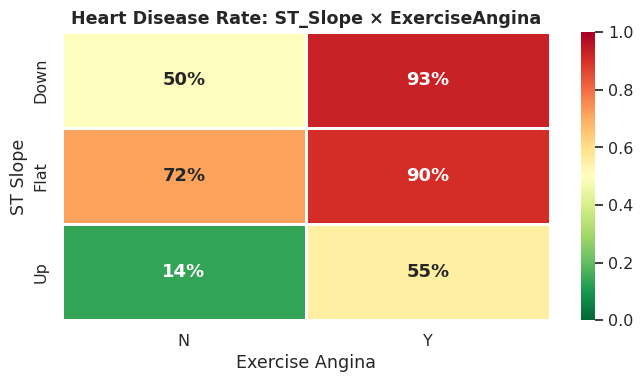

In [23]:
pivot = df.groupby(['ST_Slope', 'ExerciseAngina'])['HeartDisease'].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r',
            linewidths=1, linecolor='white', ax=ax,
            vmin=0, vmax=1, annot_kws={'size': 13, 'fontweight': 'bold'})
ax.set_title('Heart Disease Rate: ST_Slope × ExerciseAngina', fontweight='bold')
ax.set_xlabel('Exercise Angina')
ax.set_ylabel('ST Slope')
plt.tight_layout()
plt.show()

**Striking finding:** Patients with `ST_Slope = Down` **AND** `ExerciseAngina = Y` have a **100% heart disease rate** in this dataset. The combination of Flat/Down slope with exercise-induced angina is an extremely strong indicator.

##10. Correlation Analysis

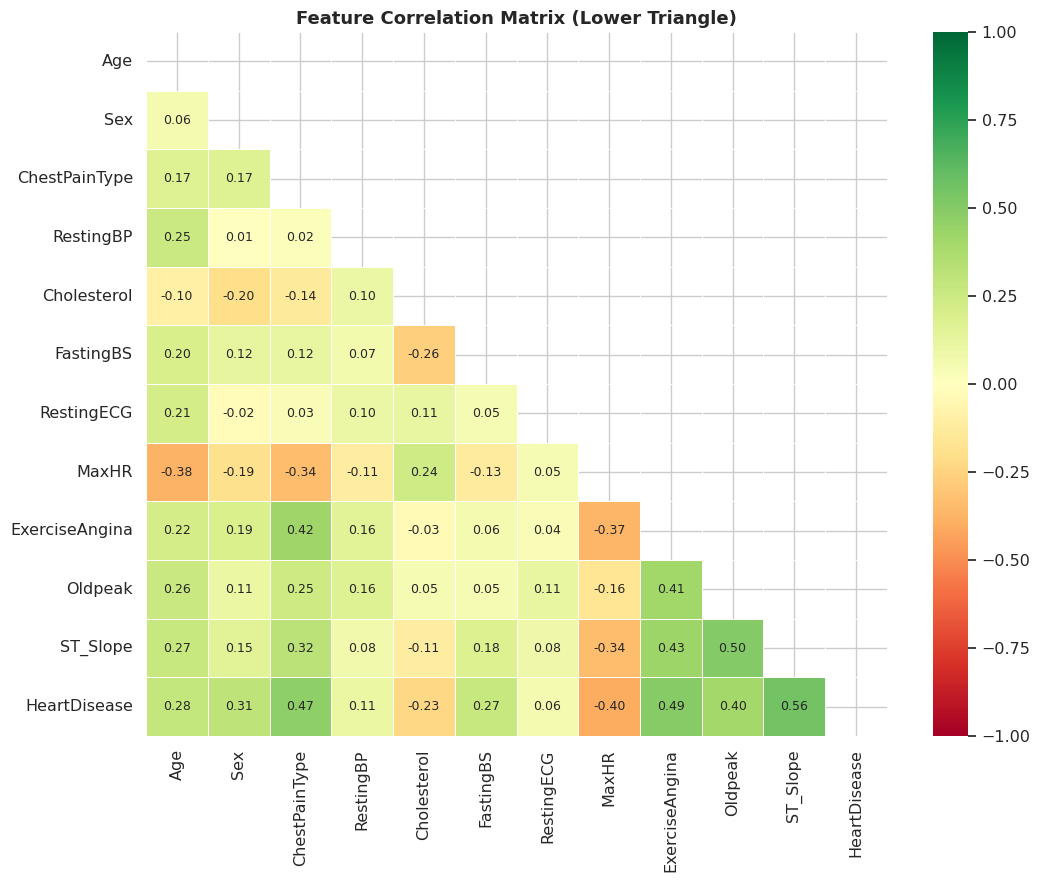

In [24]:
# Encode categoricals for correlation
df_enc = df.copy()
df_enc['Sex']            = df_enc['Sex'].map({'M': 1, 'F': 0})
df_enc['ExerciseAngina'] = df_enc['ExerciseAngina'].map({'Y': 1, 'N': 0})
df_enc['ChestPainType']  = df_enc['ChestPainType'].map({'ASY': 3, 'NAP': 2, 'ATA': 1, 'TA': 0})
df_enc['ST_Slope']       = df_enc['ST_Slope'].map({'Down': 2, 'Flat': 1, 'Up': 0})
df_enc['RestingECG']     = df_enc['RestingECG'].map({'LVH': 2, 'ST': 1, 'Normal': 0})

corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, linecolor='white',
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

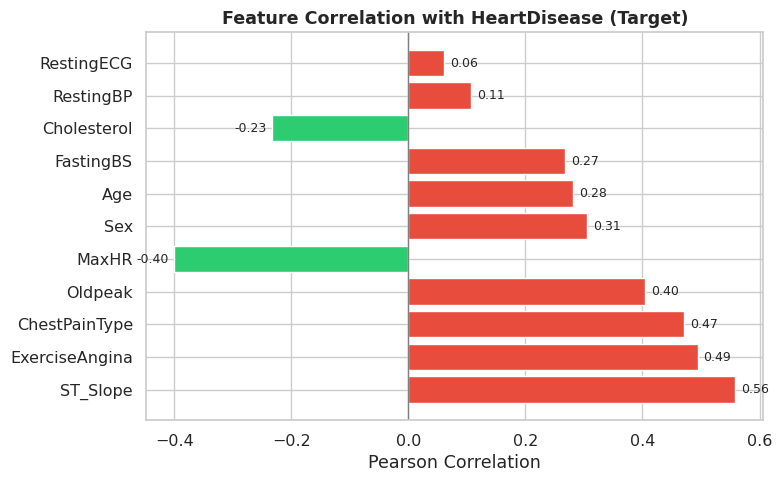

In [25]:
# Correlations with target, sorted
target_corr = corr['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [COLOR_H if v > 0 else COLOR_N for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=1)
ax.set_title('Feature Correlation with HeartDisease (Target)', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.01 if val > 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

**Top correlates with HeartDisease:**
1. `ST_Slope` — strongest (higher encoded value = more dangerous slope)
2. `ExerciseAngina` — exercise-induced pain is a powerful signal
3. `ChestPainType` — ASY type dominates
4. `MaxHR` — lower MaxHR associates with disease (negative correlation)
5. `Oldpeak` — higher ST depression = higher risk

**No severe multicollinearity** between features (all inter-feature correlations < 0.6), which is favorable for many models.

## 11. Pair Plot — Key Features

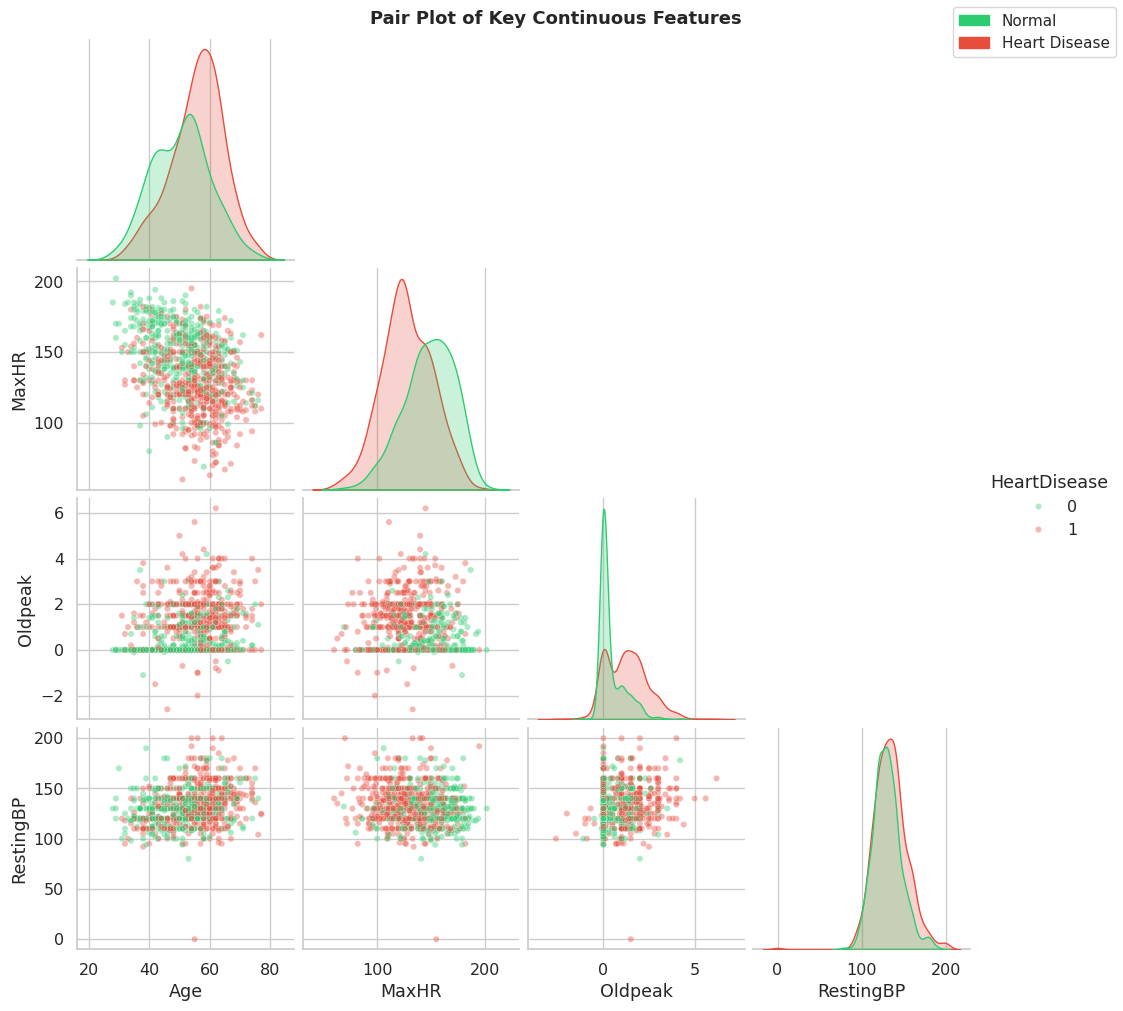

In [26]:
pair_feats = ['Age', 'MaxHR', 'Oldpeak', 'RestingBP', 'HeartDisease']
g = sns.pairplot(df[pair_feats], hue='HeartDisease',
                 palette={0: COLOR_N, 1: COLOR_H},
                 diag_kind='kde', plot_kws=dict(alpha=0.4, s=20),
                 corner=True)
g.figure.suptitle('Pair Plot of Key Continuous Features', y=1.01, fontsize=13, fontweight='bold')
handles = [mpatches.Patch(color=COLOR_N, label='Normal'),
           mpatches.Patch(color=COLOR_H, label='Heart Disease')]
g.figure.legend(handles=handles, loc='upper right', fontsize=11)
plt.show()

##12. Feature Engineering Suggestions

Based on the EDA, here are concrete recommendations for feature engineering before modeling:

In [35]:
suggestions = {
    'Feature / Issue': [
        'Cholesterol = 0 (172 records)',
        'RestingBP = 0 (1 record)',
        'Cholesterol (skewed, outliers)',
        'Age (continuous)',
        'Oldpeak (right-skewed)',
        'Sex, ExerciseAngina',
        'ChestPainType, RestingECG, ST_Slope',
        'ST_Slope × ExerciseAngina (interaction)',
        'MaxHR × Age (interaction)',
    ],
    'Recommendation': [
        'Impute with median of valid values; add binary flag Cholesterol_missing',
        'Impute with median or drop the single record',
        'Apply log transformation or RobustScaler',
        'Optional: bin into age groups (e.g., <45, 45-55, 55-65, 65+)',
        'Apply log1p transformation to reduce right skew',
        'Binary encode: M→1/F→0, Y→1/N→0',
        'Ordinal or one-hot encoding based on model type',
        'Create interaction feature: high-risk combo flag',
        'Create MaxHR_age_ratio = MaxHR / Age (cardiac reserve proxy)',
    ]
}

(pd.DataFrame(suggestions).style
    .hide(axis='index')
    .set_properties(**{
        'text-align': 'left',
        'padding': '12px 18px',
        'font-size': '15px',
        'color': '#222',
        'border-bottom': '1px solid #eee'
    })
    .set_table_styles([

        {'selector': 'th', 'props': [
            ('text-align', 'left'),
            ('font-size', '14px'),
            ('font-weight', '800'),
            ('background-color', '#f9f9f9'),
            ('color', '#000'),
            ('border-bottom', '2px solid #333')
        ]},

        {'selector': '', 'props': [
            ('font-family', 'Segoe UI, Arial, sans-serif'),
            ('border-collapse', 'collapse'),
            ('width', 'auto'),
            ('max-width', '600px'),
            ('margin-left', '0')
        ]}
    ])
)


Feature / Issue,Recommendation
Cholesterol = 0 (172 records),Impute with median of valid values; add binary flag Cholesterol_missing
RestingBP = 0 (1 record),Impute with median or drop the single record
"Cholesterol (skewed, outliers)",Apply log transformation or RobustScaler
Age (continuous),"Optional: bin into age groups (e.g., <45, 45-55, 55-65, 65+)"
Oldpeak (right-skewed),Apply log1p transformation to reduce right skew
"Sex, ExerciseAngina","Binary encode: M→1/F→0, Y→1/N→0"
"ChestPainType, RestingECG, ST_Slope",Ordinal or one-hot encoding based on model type
ST_Slope × ExerciseAngina (interaction),Create interaction feature: high-risk combo flag
MaxHR × Age (interaction),Create MaxHR_age_ratio = MaxHR / Age (cardiac reserve proxy)


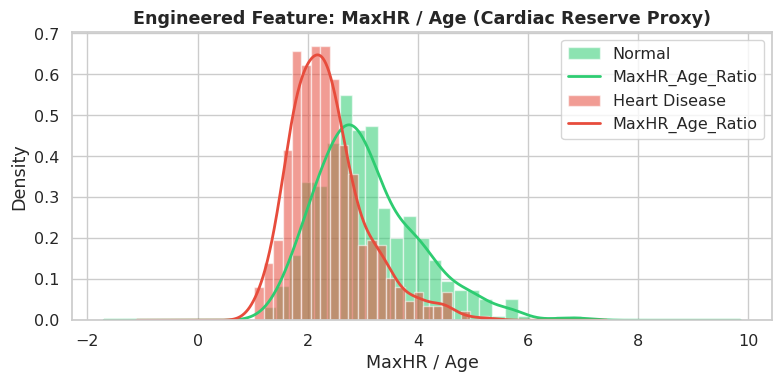

Mean MaxHR/Age — Normal: 3.08  |  Heart Disease: 2.37


In [28]:
# Demo: MaxHR / Age ratio
df_demo = df.copy()
df_demo['MaxHR_Age_Ratio'] = df_demo['MaxHR'] / df_demo['Age']

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in zip([0, 1], PALETTE, ['Normal', 'Heart Disease']):
    sub = df_demo[df_demo['HeartDisease'] == label]['MaxHR_Age_Ratio']
    ax.hist(sub, bins=25, alpha=0.55, color=color, density=True, label=name)
    sub.plot.kde(ax=ax, color=color, linewidth=2)
ax.set_title('Engineered Feature: MaxHR / Age (Cardiac Reserve Proxy)', fontweight='bold')
ax.set_xlabel('MaxHR / Age')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

r0 = df_demo[df_demo['HeartDisease']==0]['MaxHR_Age_Ratio'].mean()
r1 = df_demo[df_demo['HeartDisease']==1]['MaxHR_Age_Ratio'].mean()
print(f'Mean MaxHR/Age — Normal: {r0:.2f}  |  Heart Disease: {r1:.2f}')

The engineered `MaxHR/Age` ratio provides **cleaner separation** between classes than MaxHR alone — demonstrating the value of domain-informed feature engineering.

##13. Conclusions

###Dataset Summary

| Aspect | Finding |
|---|---|
| **Size** | 918 patients, 11 features, 1 target |
| **Balance** | Mild imbalance (55% disease / 45% normal) |
| **Null values** | No explicit NaN — but 172 Cholesterol zeros are hidden missing values |
| **Outliers** | Present in Cholesterol and Oldpeak, mostly medically plausible |
| **Demographics** | Mostly male patients (79%), age range 28–77, mean 53.5 years |

###Key Findings

1. **ExerciseAngina + ST_Slope** are the most powerful combination. Patients with exercise-induced angina and a flat/downward ST slope have extremely high disease probability.

2. **Asymptomatic chest pain** (ASY type) is counterintuitively the most dangerous — nearly 80% of ASY patients have heart disease. Silent disease is often the most advanced.

3. **MaxHR** decreases significantly in diseased patients — the heart's inability to accelerate under stress is a reliable signal.

4. **Cholesterol** is a surprisingly weak direct predictor in this dataset (possibly due to the 18.7% missing-as-zero values masking the true relationship).

5. **Sex imbalance** (79% male) means findings for female patients should be interpreted carefully — the model may underperform for women.

###Modeling Readiness

- **Before modeling:** impute Cholesterol zeros, encode categoricals, optionally add interaction features.
- **Recommended features to prioritize:** `ST_Slope`, `ExerciseAngina`, `ChestPainType`, `MaxHR`, `Oldpeak`, `Sex`.
- **Suitable models:** Logistic Regression (baseline), Random Forest, XGBoost — all well-suited for this binary classification problem with mixed feature types.
- **Evaluation metric:** Use F1-score / AUC-ROC rather than accuracy alone, given the slight imbalance and the medical cost asymmetry (false negatives are more dangerous than false positives).